## ML Pipeline 4 — What drives lifetime giving? (explanatory / associational)

### 1) Problem framing

**Business question:** After controlling for how often someone gives and how long they have been active, which **acquisition channels** and **supporter types** are associated with **higher total lifetime donation volume**? Leadership wants to know where high-value relationships tend to come from—not only churn risk.

**Who cares:** Fundraising leadership and the board, for **strategy and budgeting** (where to invest acquisition effort), not for real-time scoring.

**Outcome (target):** `log_total = log(1 + lifetime_total_amount)` at the supporter level. Donation totals are **right-skewed**; modeling on a log scale stabilizes variance and keeps dummy-variable effects easier to interpret as approximate proportional shifts in `(1 + total)` relative to a reference category, holding other modeled factors fixed.

**Success metrics:** For **explanation**, we want **defensible OLS coefficients** with uncertainty (HC3 SEs), sensible signs, and a clear story for leadership. For **prediction**, we want **out-of-sample** RMSE / R² (and a Gaussian log-likelihood score) from a **CV-tuned** model chosen **without** using the hold-out test set during selection.

**Prediction vs explanation:** This notebook is **primarily explanatory** (associations in observational data). **Selection bias** is severe (people self-select into channels): we **do not** claim that changing channel *causes* higher giving. In the course rubric, “causal / relationship analysis” here means **interpretable, defensible associations** (not a causal-identification design like an experiment). We still fit a **predictive** benchmark (Ridge / random forest / gradient boosting with CV) to compare error and to summarize **feature importances** alongside coefficients—without treating better predictions as causal proof.


### How to read this notebook (undergrad-friendly walkthrough)

This notebook mixes **explanation** (what tends to co-occur with higher lifetime giving in *historical* data?) with a **predictive benchmark** (how well can we guess `log_total` out-of-sample?). It is **not** a randomized experiment: channels and supporter types are **self-selected**, so coefficients are **associations**, not proof that "if we force everyone through channel X, revenue doubles."

**Stages:**

1. **Setup & load** — Same CSV pattern as other pipelines: `supporters` + `donations`, typed columns.
2. **Aggregate to supporter level** — One row per `supporter_id`: sum gifts, count gifts, first/last dates, tenure. Merge static attributes (region, acquisition channel, etc.). `log_total = log(1 + total_amount)` tames **right-skewed** dollar amounts so regression is more stable.
3. **EDA** — Histograms/scatterplots build intuition before modeling (always look before you fit).
4. **OLS (statsmodels)** — A **formula** string describes the regression (`log_total ~ predictors`). **HC3** standard errors relax the "constant variance" assumption. Read coefficients as "holding other modeled terms fixed, this category differs from the reference category by about this much on the log scale."
5. **Predictive models (sklearn)** — Ridge / tree ensembles with cross-validation give **RMSE / R²** and **feature importances** as a parallel story to OLS.
6. **Fairness-style slices** — Error broken out by region or cohort checks whether the model is systematically worse for some groups (audit, not legal compliance).
7. **Robustness** — Splitting by first-gift era tests whether relationships are stable across time.

**Vocabulary:** *Heteroskedasticity* = error spread changes with X; *regularization* = Ridge shrinks coefficients to reduce overfitting.


In [17]:
# -----------------------------------------------------------------------------
# Stage: imports, plotting defaults, and DATA_DIR resolution
# -----------------------------------------------------------------------------
# statsmodels/patsy handle formula-based regression; sklearn handles CV-tuned ML.
# DATA_DIR tries ./data/lighthouse_csv_v7 first, then falls back to the author's path—edit for your machine.
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm

from IPython.display import display

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_val_predict,
    train_test_split,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Plot defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5)})

# Optional
try:
    import seaborn as sns  # type: ignore

    HAVE_SEABORN = True
except Exception:
    HAVE_SEABORN = False


def style_axes(ax: plt.Axes, *, rotate_x: int = 0) -> None:
    if rotate_x:
        for label in ax.get_xticklabels():
            label.set_rotation(rotate_x)
            label.set_horizontalalignment("right")
    ax.grid(True, axis="y", alpha=0.3)


# Update if needed — place CSVs in ./data/lighthouse_csv_v7 next to this notebook, or edit the fallback path
DATA_DIR = Path("data") / "lighthouse_csv_v7"
if not DATA_DIR.is_dir():
    DATA_DIR = Path(r"C:\Users\MaxJO\Downloads\lighthouse_csv_v7")
assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"


DATA_DIR: C:\Users\MaxJO\Downloads\lighthouse_csv_v7


In [18]:
# -----------------------------------------------------------------------------
# Stage: ingest the two relational tables
# -----------------------------------------------------------------------------
supporters = pd.read_csv(DATA_DIR / "supporters.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")

# Basic parsing
if "donation_date" in donations.columns:
    donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")
if "amount" in donations.columns:
    donations["amount"] = pd.to_numeric(donations["amount"], errors="coerce")

supporters.shape, donations.shape

((60, 15), (420, 13))

### 2) Data acquisition, preparation & exploration

We aggregate to **one row per supporter** with lifetime totals from `donations`, then merge **static attributes** from `supporters`. Only supporters with at least one non-missing `amount` are kept.

- **Join:** supporter-level gift totals merged to **one** row per `supporter_id` from `supporters` (`validate='many_to_one'`).
- **Reproducibility (Ch. 7):** Deterministic pandas only—re-run the notebook top-to-bottom to reproduce `model_df` and all model fits.


In [19]:
# -----------------------------------------------------------------------------
# Stage: build one modeling row per supporter (lifetime outcomes + static traits)
# -----------------------------------------------------------------------------
# groupby.agg collapses many gift rows into totals; merge brings in demographics.
# Categoricals are filled with "Unknown" so patsy/sklearn never see NaN category labels.
d = donations.dropna(subset=["supporter_id", "amount"]).copy()
agg = (
    d.groupby("supporter_id", as_index=False)
    .agg(
        total_amount=("amount", "sum"),
        n_donations=("amount", "count"),
        first_donation=("donation_date", "min"),
        last_donation=("donation_date", "max"),
    )
)
agg["tenure_days"] = (agg["last_donation"] - agg["first_donation"]).dt.days.clip(lower=0).astype(float)

s_cols = [
    c
    for c in [
        "supporter_id",
        "supporter_type",
        "acquisition_channel",
        "relationship_type",
        "region",
        "country",
    ]
    if c in supporters.columns
]
sup_unique = supporters[s_cols].drop_duplicates(subset=["supporter_id"], keep="first")
model_df = agg.merge(sup_unique, on="supporter_id", how="left", validate="many_to_one")

cat_cols = [
    c
    for c in ["supporter_type", "acquisition_channel", "relationship_type", "region", "country"]
    if c in model_df.columns
]
for c in cat_cols:
    model_df[c] = model_df[c].fillna("Unknown").astype(str)

model_df["log_total"] = np.log1p(model_df["total_amount"])
model_df["log_n"] = np.log1p(model_df["n_donations"])

model_df.head(), model_df.shape

(   supporter_id  total_amount  n_donations first_donation last_donation  tenure_days       supporter_type acquisition_channel  \
 0             1       7567.97            7     2023-03-25    2026-02-19       1062.0  SocialMediaAdvocate         SocialMedia   
 1             2       3480.08            2     2023-03-08    2023-08-07        152.0            Volunteer         SocialMedia   
 2             3       9225.71            9     2023-02-22    2025-09-13        934.0        MonetaryDonor         SocialMedia   
 3             4       8694.73            8     2023-11-07    2026-03-01        845.0        MonetaryDonor              Church   
 4             5       4738.58            4     2023-12-20    2025-10-02        652.0          InKindDonor             Website   
 
      relationship_type    region      country  log_total     log_n  
 0                Local     Luzon  Philippines   8.931812  2.079442  
 1                Local  Mindanao  Philippines   8.155098  1.098612  
 2      

**EDA:** We inspect **distributions** (heavy tails on raw totals), **bivariate** patterns vs engagement and tenure, **numeric summaries** and **correlations** among continuous inputs, and **category frequencies** for key fields. Findings inform the log transform and the choice to control for `log_n` and `tenure_days` before interpreting channel/type effects.

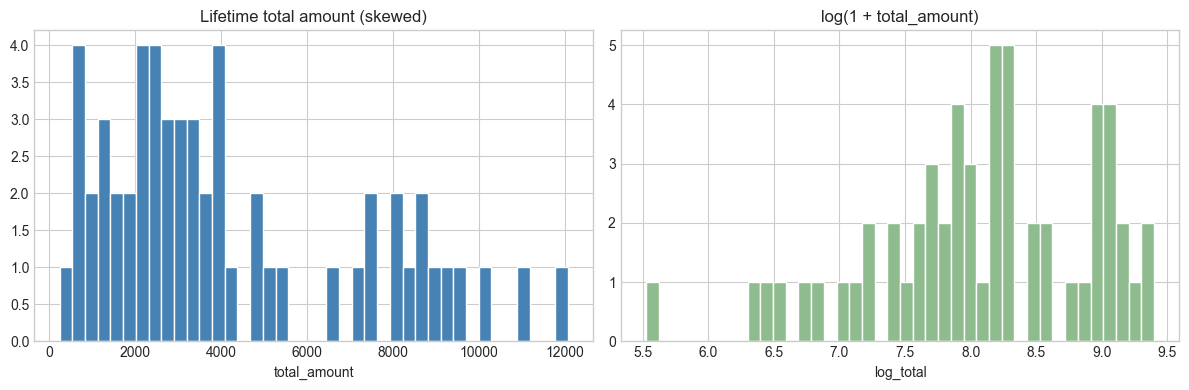

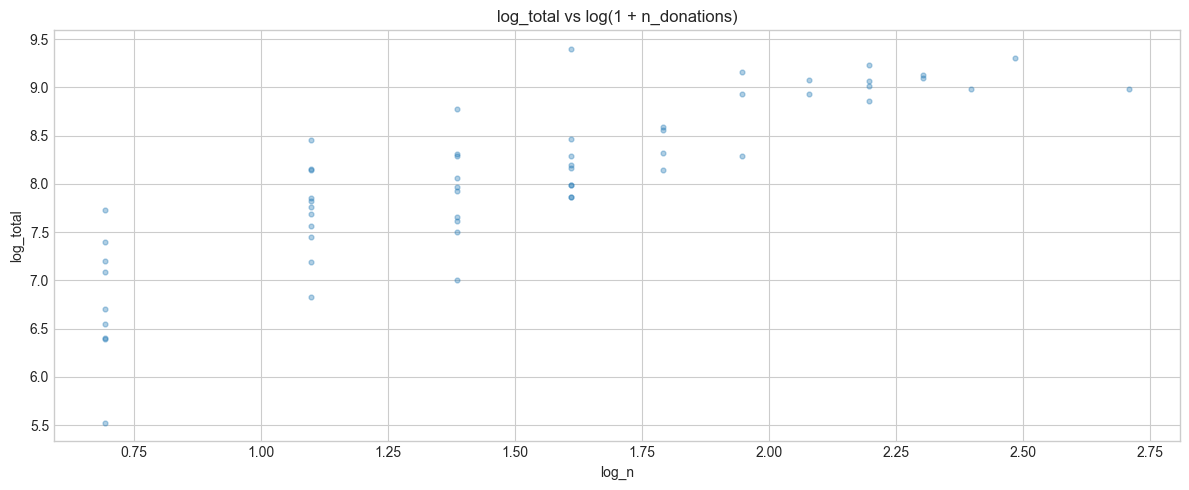

In [20]:
# -----------------------------------------------------------------------------
# Stage: visual sanity checks before fitting equations
# -----------------------------------------------------------------------------
# Histograms show skew; scatterplots show crude curvature/outliers driving OLS leverage.
# Quick EDA: distributions + log_total vs engagement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model_df["total_amount"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Lifetime total amount (skewed)")
axes[0].set_xlabel("total_amount")

axes[1].hist(model_df["log_total"], bins=40, color="darkseagreen", edgecolor="white")
axes[1].set_title("log(1 + total_amount)")
axes[1].set_xlabel("log_total")
plt.tight_layout()
plt.show()

ax = model_df.plot.scatter(x="log_n", y="log_total", alpha=0.35, s=12)
ax.set_title("log_total vs log(1 + n_donations)")
plt.tight_layout()
plt.show()

#### Further exploration (distributions, levels, associations)

Numeric columns: central tendency, spread, and **Tukey-style fence** counts on `total_amount` to flag extreme skew (we do not drop outliers here—we model `log_total`, which down-weights extremes, and note sensitivity in the write-up). Correlations among `log_total`, `log_n`, and `tenure_days` show how much overlap there is between frequency, tenure, and the outcome (multicollinearity is moderate for categoricals via dummies; continuous correlations help intuition).

In [21]:
# -----------------------------------------------------------------------------
# Stage: deeper tables/figures — correlations, category means, simple regressions
# -----------------------------------------------------------------------------
# These blocks are still "understand the data," not deploy a model. Use them to spot
# odd categories, sparse levels, or nonlinearities OLS will struggle with.
num_cols = [c for c in ["total_amount", "log_total", "log_n", "tenure_days", "n_donations"] if c in model_df.columns]
display(model_df[num_cols].describe(percentiles=[0.05, 0.5, 0.95]).T)

q1, q3 = model_df["total_amount"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 3 * iqr, q3 + 3 * iqr
out_mask = (model_df["total_amount"] < low) | (model_df["total_amount"] > high)
print(f"total_amount outside 3×IQR fences: {out_mask.sum()} rows ({100 * out_mask.mean():.2f}%)")

corr_cols = [c for c in ["log_total", "log_n", "tenure_days"] if c in model_df.columns]
print("\nPearson correlation (continuous):")
print(model_df[corr_cols].corr().round(3).to_string())

for c in ["acquisition_channel", "supporter_type", "relationship_type"]:
    if c in model_df.columns:
        print(f"\nTop levels by count — {c}:")
        print(model_df[c].value_counts().head(8).to_string())

,count,mean,std,min,5%,50%,95%,max
total_amount,57.0,4223.237544,3049.385882,250.000000,676.608000,3432.500000,9620.174000,12059.470000
log_total,57.0,8.051103,0.846295,5.525453,6.516901,8.141335,9.171279,9.397688
log_n,57.0,1.488062,0.533473,0.693147,0.693147,1.386294,2.321647,2.708050
tenure_days,57.0,539.438596,356.477460,0.000000,0.000000,590.000000,1011.000000,1062.000000
n_donations,57.0,4.105263,2.888921,1.000000,1.000000,3.000000,9.200000,14.000000


total_amount outside 3×IQR fences: 0 rows (0.00%)

Pearson correlation (continuous):
             log_total  log_n  tenure_days
log_total        1.000  0.841        0.721
log_n            0.841  1.000        0.836
tenure_days      0.721  0.836        1.000

Top levels by count — acquisition_channel:
acquisition_channel
SocialMedia        13
WordOfMouth        13
Website            11
Event               8
Church              6
PartnerReferral     6

Top levels by count — supporter_type:
supporter_type
MonetaryDonor          16
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               7
SkillsContributor       5
PartnerOrganization     4

Top levels by count — relationship_type:
relationship_type
Local                  33
PartnerOrganization    13
International          11


### 3) Modeling, feature selection, evaluation

We use **OLS with heteroskedasticity-robust (HC3) standard errors** for **interpretation** (coefficients and confidence intervals on the Patsy design matrix). For **prediction**, we compare **Ridge**, **random forest**, and **gradient boosting**; each is tuned with **`RandomizedSearchCV`** on **KFold** splits of the **training** rows only. The winner is chosen by **higher** `best_score_` (**`neg_root_mean_squared_error`**, i.e. lower RMSE in CV). The **held-out test** set is used only for **final reporting** (R², RMSE, MAE, Gaussian NLL), not for picking hyperparameters.

**Train/test:** Random **80/20** row split (`random_state=42`) for the linear and supervised models on the same `X`. **`sklearn` `LinearRegression`** matches **OLS** on that design (no penalty); we use it for quick test predictions before printing `statsmodels` inference.

**Chronological check:** We also refit the **linear** model on supporters with **first_donation** on or before the median date and score **newer** cohorts with aligned columns. If performance collapses, treat channel/type narratives as **time-sensitive**.

#### Feature set and selection (Ch. 16)

**Included:** `log_n` = log(1 + number of donations) controls for **engagement frequency** so channel/type coefficients are not only proxies for “gives more often.” `tenure_days` captures span from first to last observed gift. Categoricals describe **how the supporter entered the file** and coarse geography.

**Excluded:** Raw `total_amount` on the right-hand side (it is the outcome before transform). We do not use future information.

**Why OLS for explanation:** Transparent **linear** structure plus **HC3** SEs is appropriate for leadership-facing interpretation. **Trees and boosting** are **predictive** tools here; we do not read their importances as causal effects.

#### Predictive models (CV)

**Ridge**, **RandomForestRegressor**, and **GradientBoostingRegressor** share the **same** encoded design matrix. **`mean_gaussian_nll`** in the next code cell reports a **regression analogue** of a proper scoring rule (related to “log loss” for continuous outcomes); `sklearn.metrics.log_loss` is **not** used because the target is not discrete classes.

**Code cells below:** (1) fit **OLS / LinearRegression** and print the summary; (2) run **RandomizedSearchCV** for the three candidates, **select** the CV winner, and evaluate on the **test** set.


In [22]:
# -----------------------------------------------------------------------------
# Stage: OLS + sklearn benchmarks (train/validation design lives in this cell)
# -----------------------------------------------------------------------------
# patsy C() expands categoricals into dummies; the first level is the reference.
# RandomizedSearchCV tunes ML models; compare their test error to OLS for a full picture.
FORMULA = (
    "log_total ~ log_n + tenure_days + C(supporter_type) + C(acquisition_channel)"
    " + C(relationship_type) + C(region) + C(country)"
)

y_mat, X_mat = patsy.dmatrices(FORMULA, model_df, return_type="dataframe")
y_vec = y_mat.iloc[:, 0].to_numpy()
X_df = X_mat

idx_train, idx_test = train_test_split(
    np.arange(len(model_df)),
    test_size=0.2,
    random_state=42,
)
X_tr, X_te = X_df.iloc[idx_train], X_df.iloc[idx_test]
y_tr, y_te = y_vec[idx_train], y_vec[idx_test]

lr = LinearRegression()
lr.fit(X_tr, y_tr)
pred_te = lr.predict(X_te)

print("Hold-out (20 pct random rows, same design matrix as OLS):")
print("  R2 (test):", round(r2_score(y_te, pred_te), 4))
print("  RMSE (test, log scale):", round(root_mean_squared_error(y_te, pred_te), 4))
print("  MAE (test, log scale):", round(mean_absolute_error(y_te, pred_te), 4))

ols = sm.OLS(y_tr, X_tr).fit(cov_type="HC3")
print(ols.summary().as_text())

coef_abs = pd.Series(np.abs(ols.params.values), index=X_tr.columns)
if "Intercept" in coef_abs.index:
    coef_abs = coef_abs.drop("Intercept")
print("\nLargest |OLS coefficient| (train, explanatory leg) — inspect signs in summary above:")
print(coef_abs.sort_values(ascending=False).head(15).to_string())

Hold-out (20 pct random rows, same design matrix as OLS):
  R2 (test): 0.7144
  RMSE (test, log scale): 0.4347
  MAE (test, log scale): 0.3557
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     9.455
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.78e-07
Time:                        17:58:10   Log-Likelihood:                -16.221
No. Observations:                  45   AIC:                             70.44
Df Residuals:                      26   BIC:                             104.8
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                                  coef    std err  

c:\Users\MaxJO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 18
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# -----------------------------------------------------------------------------
# Stage: helper metric — Gaussian negative log-likelihood (optional scoring)
# -----------------------------------------------------------------------------
# Treats residuals as normal around predictions; lower = better density fit. Useful alongside RMSE.
def mean_gaussian_nll(y_true: np.ndarray, y_pred: np.ndarray, sigma2: float | None = None) -> float:
    """Mean negative log-likelihood under homoskedastic Gaussian errors.

    This is the regression analogue of a proper scoring rule (related to "log loss")
    for density forecasting). sklearn's `log_loss` is only for classification.

    If sigma2 is None, use the MLE variance of residuals (can be computed on train
    or test depending on what you pass in).
    """
    resid = y_true - y_pred
    if sigma2 is None:
        sigma2 = float(np.mean(resid**2)) + 1e-12
    else:
        sigma2 = float(sigma2) + 1e-12
    nll = 0.5 * (np.log(2 * np.pi * sigma2) + (resid**2) / sigma2)
    return float(np.mean(nll))


# --- CV setup (training rows only) ---
_n = len(y_tr)
n_splits = int(min(5, max(3, _n // 8)))
n_splits = max(2, min(n_splits, _n - 1))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

scoring = "neg_root_mean_squared_error"
n_iter = 24
random_state = 42

ridge_search = RandomizedSearchCV(
    Ridge(random_state=random_state),
    param_distributions={"alpha": np.logspace(-4, 4, 60)},
    n_iter=n_iter,
    cv=cv,
    scoring=scoring,
    random_state=random_state,
    n_jobs=-1,
)
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=random_state),
    param_distributions={
        "n_estimators": [80, 120, 200, 300],
        "max_depth": [2, 3, 4, 5, 6, None],
        "min_samples_leaf": [1, 2, 3, 4, 6],
    },
    n_iter=n_iter,
    cv=cv,
    scoring=scoring,
    random_state=random_state,
    n_jobs=-1,
)
gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=random_state),
    param_distributions={
        "n_estimators": [80, 120, 180, 220],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.03, 0.05, 0.07, 0.1, 0.12],
        "min_samples_leaf": [2, 3, 4, 6, 8],
    },
    n_iter=max(n_iter, 28),
    cv=cv,
    scoring=scoring,
    random_state=random_state,
    n_jobs=-1,
)

print("Fitting RandomizedSearchCV (Ridge, RandomForest, GradientBoosting)...")
ridge_search.fit(X_tr, y_tr)
rf_search.fit(X_tr, y_tr)
gbr_search.fit(X_tr, y_tr)

rows = []
for name, srch in [
    ("Ridge", ridge_search),
    ("RandomForest", rf_search),
    ("GradientBoosting", gbr_search),
]:
    pred_cv = cross_val_predict(srch.best_estimator_, X_tr, y_tr, cv=cv, n_jobs=-1)
    nll_cv = mean_gaussian_nll(y_tr, pred_cv)
    rows.append(
        {
            "model": name,
            "cv_neg_RMSE_mean": round(srch.best_score_, 5),
            "best_params": srch.best_params_,
            "cv_mean_gaussian_nll": round(nll_cv, 4),
        }
    )

cv_summary = pd.DataFrame(rows).set_index("model")
print("\nCV summary (higher neg_RMSE is better; lower Gaussian NLL is better):")
display(cv_summary[["cv_neg_RMSE_mean", "cv_mean_gaussian_nll"]])
for _, r in cv_summary.reset_index().iterrows():
    print(f"  {r['model']} best_params: {r['best_params']}")

best_name, best_search = max(
    [
        ("Ridge", ridge_search),
        ("RandomForest", rf_search),
        ("GradientBoosting", gbr_search),
    ],
    key=lambda t: t[1].best_score_,
)
best_reg = best_search.best_estimator_
print(f"\nSelected predictive model (best mean CV neg_RMSE): {best_name}")

pred_te_best = best_reg.predict(X_te)
sigma2_train = float(np.mean((y_tr - best_reg.predict(X_tr)) ** 2)) + 1e-12

print("\nHold-out vs linear OLS (same design matrix):")
print("  Linear R2 (test):", round(r2_score(y_te, pred_te), 4))
print(f"  {best_name} R2 (test):", round(r2_score(y_te, pred_te_best), 4))
print("  Linear RMSE (test):", round(root_mean_squared_error(y_te, pred_te), 4))
print(f"  {best_name} RMSE (test):", round(root_mean_squared_error(y_te, pred_te_best), 4))
print("  Linear MAE (test):", round(mean_absolute_error(y_te, pred_te), 4))
print(f"  {best_name} MAE (test):", round(mean_absolute_error(y_te, pred_te_best), 4))

sig_lin = float(np.mean((y_tr - lr.predict(X_tr)) ** 2)) + 1e-12
print("\nMean Gaussian NLL on TEST (sigma^2 from TRAIN residuals of each model):")
print("  Linear:", round(mean_gaussian_nll(y_te, pred_te, sigma2=sig_lin), 4))
print(f"  {best_name}:", round(mean_gaussian_nll(y_te, pred_te_best, sigma2=sigma2_train), 4))

if hasattr(best_reg, "feature_importances_"):
    imp = pd.Series(best_reg.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    print(f"\nTop 18 feature importances ({best_name}; impurity-based):")
    print(imp.head(18).to_string())
    top_plot = imp.head(18).sort_values()
    fig_imp, ax_imp = plt.subplots(figsize=(10, 7))
    top_plot.plot.barh(ax=ax_imp, color="teal", alpha=0.85)
    ax_imp.set_title(f"CV-selected model — top importances ({best_name})")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_reg.coef_, index=X_tr.columns)
    coefs = coefs.drop("Intercept", errors="ignore")
    topc = coefs.abs().sort_values(ascending=False).head(18)
    print(f"\nLargest |Ridge coef| (excluding intercept if present):\n{topc.to_string()}")


#### Evaluation: metrics, errors in context, and fairness

The following interprets the **test** metrics printed in the modeling cells above.

**Metrics:** We report **R²**, **RMSE**, and **MAE** on `log_total` for the **linear** model and the **CV-selected** supervised model. We also report **mean Gaussian negative log-likelihood** on the test set (with variance **estimated from training residuals** for each model): lower is better, and it plays a role analogous to **log loss** for **continuous** outcomes. `sklearn.metrics.log_loss` applies to **classification** only and is not used here.

**False positives vs false negatives (regression analogue):** There is no single 0/1 threshold, but the same tradeoffs appear when the model is used to **rank or segment** supporters by predicted `log_total`:
- **False positive (over-predict)** — Predicted `log_total` is **higher** than realized giving (large **positive** residual if we trust the model for targeting). *Cost:* **over-invest** in acquisition or stewardship paths that look strong in the model but do not pay off in realized gifts; wasted staff time and budget.
- **False negative (under-predict)** — Predicted `log_total` is **lower** than realized giving (large **negative** residual). *Cost:* **under-invest** in channels or segments that actually produce durable, high-value donors; missed revenue and weaker relationship building.

Because fundraising decisions are **capacity-constrained**, the practical use is often **prioritization** (which channels or segments to study or test next), not treating the prediction as cash-in-hand. Combine quantitative segments with **qualitative** fundraising judgment and, where possible, **experiments** before reallocating spend.

**Fairness:** The next code cell summarizes **mean absolute error on the test set by `region`** for the linear model (minimum count threshold). This is a light **error-equity** check, not a full audit. Monitor performance across segments before high-stakes use.

**Residuals:** Positive residuals mean the supporter gave **more** than the model expected given channel/type/tenure/frequency; negative means **less**. Use residuals to **audit** cases, not to label donors as “good” or “bad.”


In [24]:
# -----------------------------------------------------------------------------
# Stage: slice evaluation — does the linear model err more in some regions?
# -----------------------------------------------------------------------------
# Group-wise MAE highlights uneven performance; small groups are flagged with thresholds.
# Hold-out error equity: linear model MAE by region (min count threshold)
ae_linear = np.abs(y_te - pred_te)
if "region" in model_df.columns:
    reg_test = model_df.iloc[idx_test]["region"].astype(str).values
    fair_tbl = (
        pd.DataFrame({"region": reg_test, "mae_log": ae_linear})
        .groupby("region")["mae_log"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_abs_err_log", "count": "n_test"})
    )
    fair_tbl = fair_tbl[fair_tbl["n_test"] >= 5].sort_values("mean_abs_err_log", ascending=False)
    print("Test-set mean |error| on log scale by region (linear model), regions with n >= 5:")
    print(fair_tbl.to_string())
else:
    print("No region column — skip grouping.")

Test-set mean |error| on log scale by region (linear model), regions with n >= 5:
        mean_abs_err_log  n_test
region                          
Luzon           0.397783       8


#### Chronological robustness (still part of evaluation)

Supporters whose **first gift** falls **after** the median first-donation date are treated as a newer cohort. We refit the **linear** model on the **older** cohort only and report **R²** and **RMSE** on the newer cohort design matrix (columns aligned to the training design). If scores collapse relative to the random split, treat channel/type narratives as **time-sensitive**.

In [25]:
# -----------------------------------------------------------------------------
# Stage: time-stability check — "old" vs "new" cohorts by first gift date
# -----------------------------------------------------------------------------
# If coefficients flip sign between halves, the story for leadership must be conditional on era.
cut = model_df["first_donation"].median()
old_mask = model_df["first_donation"] <= cut
new_mask = model_df["first_donation"] > cut

y_old, X_old = patsy.dmatrices(FORMULA, model_df.loc[old_mask], return_type="dataframe")
y_new, X_new = patsy.dmatrices(FORMULA, model_df.loc[new_mask], return_type="dataframe")

X_new = X_new.reindex(columns=X_old.columns, fill_value=0.0)

lr_c = LinearRegression()
lr_c.fit(X_old, y_old.iloc[:, 0].to_numpy())
pred_new = lr_c.predict(X_new)
y_new_vec = y_new.iloc[:, 0].to_numpy()

print("Cohort split at median first_donation:", pd.Timestamp(cut).date())
print("  Train (older cohort) n:", len(y_old), "| Test (newer cohort) n:", len(y_new))
print("  R2 (newer cohort, model fit on older):", round(r2_score(y_new_vec, pred_new), 4))
print("  RMSE (newer cohort):", round(root_mean_squared_error(y_new_vec, pred_new), 4))

Cohort split at median first_donation: 2023-11-03
  Train (older cohort) n: 29 | Test (newer cohort) n: 28
  R2 (newer cohort, model fit on older): 0.6367
  RMSE (newer cohort): 0.545


### 4) Causal and relationship analysis

This pipeline is **primarily explanatory** (associations after conditioning on frequency and tenure). The textbook still asks for an honest discussion of **relationships** and what can (and cannot) be claimed about **cause and effect**.

**What we learn:** **OLS** describes **patterns in this anonymized sample**. Channels and types with **positive** coefficients vs the reference are associated with **higher** `log(1 + total)` among supporters with similar modeled engagement. The **CV-selected predictive** model’s **importances** (or Ridge **coefficients**) should **broadly agree** on what matters (e.g. engagement, tenure) but may rank specific dummies differently—that tension reminds us that **linear** and **flexible** models stress different parts of the signal.

**Most impactful drivers:** Use **(1)** the “Largest |OLS coefficient|” table for **direction and uncertainty** vs reference categories, and **(2)** the **importance / |coef|** summary from the **CV-winning** predictive model. Prioritize coefficients that are **stable** (reasonable sign, narrow CI) **and** show up as **important** in the flexible model; treat discordant signals as **tentative**.

**Why not causal:** Acquisition channel is **not randomly assigned**. Donors who arrive via different paths may differ on unmeasured wealth, motivation, or staff follow-up. Coefficients **do not** justify “shift budget to channel X” without experimental or quasi-experimental evidence.

**Reasonable actions (hypothesis-generating):** Propose **targeted tests** (e.g., time-blocked or geography-blocked campaigns) for channels that are positive in OLS **and** non-trivial in importances. Pair segments with **qualitative** follow-up from fundraising staff. If the **chronological** split degrades sharply, refresh models on a schedule and avoid **long-horizon** claims about channel performance.

**Limitations:** We observe **donation records**, not full donor psychology or external shocks. Any “causal story” here is **hypothesis-generating** for leadership, not a substitute for randomized evaluation.


### 5) Deployment notes

This pipeline is intended for **batch reporting**, not real-time scoring. A scheduled job can run this notebook’s ETL + fits after each data refresh and export (a) an **OLS coefficient table** with confidence intervals and (b) the **CV-selected model** metrics + importances to a small **JSON/CSV artifact** consumed by the web app’s internal analytics page. In our repo, the web/app integration is implemented in the **separate deployment pipeline** under `ml-pipelines/` (this notebook provides the model logic and the artifacts that pipeline publishes).
